In [ ]:
import os
import random
import numpy as np

import matplotlib.pyplot as plt
import cv2
import imghdr
import tensorflow as tf
from PIL import Image



from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.applications import VGG16, ResNet50V2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense, Activation, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.utils import plot_model

In [ ]:
# Directory paths for training and testing data
train_dir = 'train'
test_dir = 'test'

# Batch size for data generators
batch_size = 64

# Data augmentation configuration for training data
train_datagen = ImageDataGenerator(
                                  rescale=1 / 255.,  # Rescale pixel values to [0,1]
                                  rotation_range=10,  # Random rotation within range [-10,10] degrees
                                  zoom_range=0.2,  # Random zoom between [0.8, 1.2]
                                  width_shift_range=0.1,  # Random horizontal shift within range [-0.1, 0.1]
                                  height_shift_range=0.1,  # Random vertical shift within range [-0.1, 0.1]
                                  horizontal_flip=True,  # Random horizontal flip
                                  fill_mode='nearest'  # Fill mode for handling newly created pixels
                                 )

# Configuration for testing data (only rescaling)
test_datagen = ImageDataGenerator(
                                  rescale=1 / 255.  # Rescale pixel values to [0,1]
                                 )

# Data generators for training and testing data
train_generator = train_datagen.flow_from_directory(
                                                    train_dir,  # Directory containing training data
                                                    class_mode="categorical",  # Classification mode for categorical labels
                                                    target_size=(224, 224),  # Resize input images to (224,224)
                                                    color_mode='rgb',  # Color mode for images (RGB)
                                                    shuffle=True,  # Shuffle training data
                                                    batch_size=batch_size,  # Batch size for training
                                                    subset='training'  # Subset of data (training)
                                                   )

test_generator = test_datagen.flow_from_directory(
                                                  test_dir,  # Directory containing testing data
                                                  class_mode="categorical",  # Classification mode for categorical labels
                                                  target_size=(224, 224),  # Resize input images to (224,224)
                                                  color_mode="rgb",  # Color mode for images (RGB)
                                                  shuffle=False,  # Do not shuffle testing data
                                                  batch_size=batch_size  # Batch size for testing
                                                 )


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
# Extract class labels for all instances in the training dataset
classes = np.array(train_generator.classes)

# Calculate class weights to handle imbalances in the training data
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
class_weights = compute_class_weight(
    class_weight='balanced',  # Strategy to balance classes
    classes=np.unique(classes),  # Unique class labels
    y=classes  # Class labels for each instance in the training dataset
)

# Create a dictionary mapping class indices to their calculated weights
class_weights_dict = dict(enumerate(class_weights))

# Output the class weights dictionary
print("Class Weights Dictionary:", class_weights_dict)

Class Weights Dictionary: {0: 1.0259549973835689, 1: 7.83821961620469, 2: 1.0010211375472275, 3: 0.5743384435113759, 4: 0.8294739811028063, 5: 0.8521877716603883, 6: 1.2844040704022361}


In [ ]:
ResNet50V2 = tf.keras.applications.ResNet50V2(input_shape=(224, 224, 3),
                                               include_top= False,
                                               weights='imagenet'
                                               )

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 825s 9us/step


In [ ]:
# Freezing all layers except last 50

ResNet50V2.trainable = True

for layer in ResNet50V2.layers[:-50]:
    layer.trainable = False

In [ ]:
def Create_ResNet50V2_Model():

    model = Sequential([
                      ResNet50V2,
                      Dropout(0.25),
                      BatchNormalization(),
                      Flatten(),
                      Dense(64, activation='relu'),
                      BatchNormalization(),
                      Dropout(0.5),
                      Dense(7,activation='softmax')
                    ])
    return model

In [ ]:
model = Create_ResNet50V2_Model()
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 7, 7, 2048)     │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,996,295 (114.43 MB)

 Trainable params: 22,779,527 (86.90 MB)

 Non-trainable params: 7,216,768 (27.53 MB)

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.trainable)

0 resnet50v2 True
1 dropout_8 True
2 batch_normalization_38 True
3 flatten_3 True
4 dense_11 True
5 batch_normalization_39 True
6 dropout_9 True
7 dense_12 True


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# File path for the model checkpoint

name = 'ResNet50_Transfer_Learning.keras'


# Callback to save the model checkpoint
checkpoint = ModelCheckpoint(filepath=chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss')

# Callback for early stopping
earlystop = EarlyStopping(monitor = 'val_accuracy',
                          patience = 7,
                          restore_best_weights = True,
                          verbose=1)

# Callback to reduce learning rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=2,
#                             min_lr=0.00005,
                              verbose=1)

# Callback to log training data to a CSV file
csv_logger = CSVLogger('training.log')

# Aggregating all callbacks into a list
callbacks = [checkpoint, earlystop, csv_logger]  # Adjusted as per your use-case

train_steps_per_epoch = train_generator.samples // train_generator.batch_size + 1
# validation_steps_epoch = validation_generator.samples // validation_generator.batch_size + 1
test_steps_epoch = test_generator.samples // test_generator.batch_size + 1

In [ ]:
train_history = model.fit(
                          train_generator,
                          steps_per_epoch=train_steps_per_epoch,
                          epochs=20,
                          validation_data=test_generator,
                          validation_steps=test_steps_epoch,
                          class_weight=class_weights_dict,
                          callbacks = callbacks
                         )

Epoch 1/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3433 - loss: 1.9438

c:\Users\elfak\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 12.29837, saving model to /content/drive/MyDrive\ResNet50_Transfer_Learning.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 4080s 9s/step - accuracy: 0.3434 - loss: 1.9433 - val_accuracy: 0.2761 - val_loss: 12.2984
Epoch 2/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4663 - loss: 1.5026
Epoch 2: val_loss improved from 12.29837 to 1.29377, saving model to /content/drive/MyDrive\ResNet50_Transfer_Learning.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 3800s 8s/step - accuracy: 0.4664 - loss: 1.5025 - val_accuracy: 0.5464 - val_loss: 1.2938
Epoch 3/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5365 - loss: 1.2566
Epoch 3: val_loss did not improve from 1.29377
460/460 ━━━━━━━━━━━━━━━━━━━━ 3968s 9s/step - accuracy: 0.5365 - loss: 1.2566 - val_accuracy: 0.4132 - val_loss: 1.9210
Epoch 4/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5375 - loss: 1.2459
Epoch 4: val_loss improved from 1.29377 to 1.11011, saving model to /content/drive/MyDrive\Re

In [ ]:
# Accessing class labels for the training data
train_class_labels = train_generator.class_indices
print("Training class labels:", train_class_labels)

# Accessing class labels for the validation data
test_class_labels = test_generator.class_indices
print("Validation class labels:", test_class_labels)

Training class labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Validation class labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


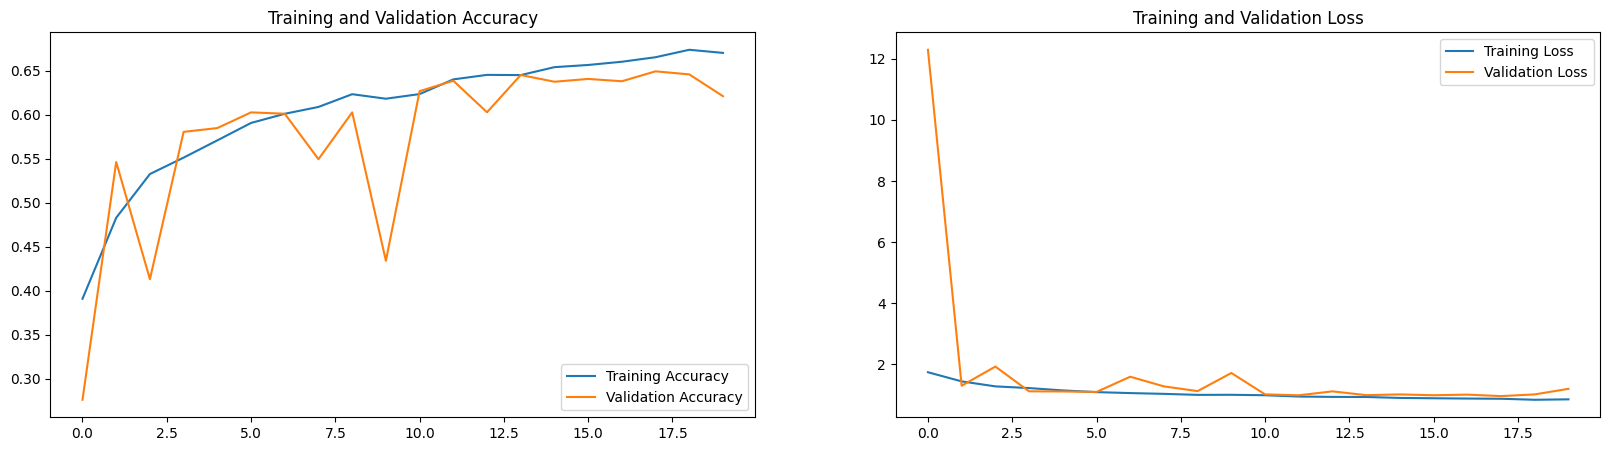

In [ ]:
def plot_training_history(history):
    """
    Plots the training and validation accuracy and loss.

    Parameters:
    - history: A Keras History object. Contains the logs from the training process.

    Returns:
    - None. Displays the matplotlib plots for training/validation accuracy and loss.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(20, 5))

    # Plot training and validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.show()




plot_training_history(train_history)

In [ ]:
model.save("Resnet_model.keras")

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.models import load_model

# 1. Charger le modèle sauvegardé
model = load_model("Resnet_model.keras")  # Remplace par le nom de ton fichier .h5

# 2. Évaluer le modèle sur le test_generator
loss, accuracy = model.evaluate(test_generator, verbose=1)
print("Loss:", loss)
print("Accuracy:", accuracy)

# 3. Faire les prédictions
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# 4. Obtenir les vraies étiquettes
y_true = test_generator.classes

# 5. Calculer le F1-score
f1 = f1_score(y_true, y_pred_classes, average='weighted')  # ou 'macro' / 'micro'
print("F1 Score (weighted):", f1)

# 6. Rapport de classification complet
target_names = list(test_generator.class_indices.keys())  # noms des classes
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=target_names))


c:\Users\elfak\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


113/113 ━━━━━━━━━━━━━━━━━━━━ 797s 7s/step - accuracy: 0.6200 - loss: 1.0265
Loss: 0.9537503719329834
Accuracy: 0.6494845151901245
113/113 ━━━━━━━━━━━━━━━━━━━━ 645s 6s/step
F1 Score (weighted): 0.6501751566974121

Classification Report:
              precision    recall  f1-score   support

       angry       0.55      0.62      0.58       958
     disgust       0.77      0.54      0.63       111
        fear       0.51      0.41      0.45      1024
       happy       0.90      0.80      0.85      1774
     neutral       0.55      0.72      0.62      1233
         sad       0.55      0.52      0.53      1247
    surprise       0.77      0.76      0.77       831

    accuracy                           0.65      7178
   macro avg       0.66      0.62      0.63      7178
weighted avg       0.66      0.65      0.65      7178



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.models import load_model

# 1. Charger le modèle sauvegardé
model = load_model("ResNet50V2_ck.keras")  # Remplace par le nom de ton fichier .h5

# 2. Évaluer le modèle sur le test_generator
loss, accuracy = model.evaluate(test_generator, verbose=1)
print("Loss:", loss)
print("Accuracy:", accuracy)

# 3. Faire les prédictions
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# 4. Obtenir les vraies étiquettes
y_true = test_generator.classes

# 5. Calculer le F1-score
f1 = f1_score(y_true, y_pred_classes, average='weighted')  # ou 'macro' / 'micro'
print("F1 Score (weighted):", f1)

# 6. Rapport de classification complet
target_names = list(test_generator.class_indices.keys())  # noms des classes
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=target_names))


113/113 ━━━━━━━━━━━━━━━━━━━━ 622s 5s/step - accuracy: 0.5522 - loss: 1.2679
Loss: 1.100834608078003
Accuracy: 0.607690155506134
113/113 ━━━━━━━━━━━━━━━━━━━━ 465s 4s/step
F1 Score (weighted): 0.60163812023432

Classification Report:
              precision    recall  f1-score   support

       angry       0.64      0.47      0.55       958
     disgust       0.66      0.67      0.66       111
        fear       0.51      0.37      0.43      1024
       happy       0.91      0.77      0.83      1774
     neutral       0.41      0.89      0.56      1233
         sad       0.61      0.28      0.39      1247
    surprise       0.74      0.78      0.76       831

    accuracy                           0.61      7178
   macro avg       0.64      0.60      0.60      7178
weighted avg       0.66      0.61      0.60      7178



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.models import load_model

# 1. Charger le modèle sauvegardé
model = load_model("mon_model.h5")  # Remplace par le nom de ton fichier .h5

# 2. Évaluer le modèle sur le test_generator
loss, accuracy = model.evaluate(test_generator, verbose=1)
print("Loss:", loss)
print("Accuracy:", accuracy)

# 3. Faire les prédictions
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# 4. Obtenir les vraies étiquettes
y_true = test_generator.classes

# 5. Calculer le F1-score
f1 = f1_score(y_true, y_pred_classes, average='weighted')  # ou 'macro' / 'micro'
print("F1 Score (weighted):", f1)

# 6. Rapport de classification complet
target_names = list(test_generator.class_indices.keys())  # noms des classes
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=target_names))


225/225 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step


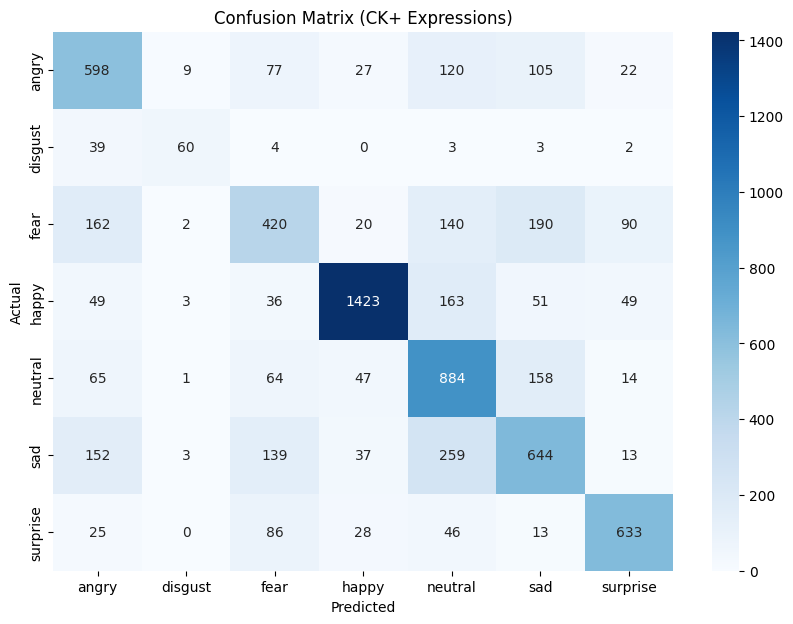

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load your saved model
model = load_model('Resnet_model.keras')

# Reset the test generator to avoid shuffling issues
test_generator.reset()

# Get all batches of test data and concatenate them
X_test = []
y_test = []

for i in range(len(test_generator)):
    x_batch, y_batch = test_generator[i]
    X_test.append(x_batch)
    y_test.append(y_batch)

# Convert lists to NumPy arrays
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

# Predict on X_test
y_pred = model.predict(X_test).argmax(axis=1)  # Get class indices from softmax output

# Convert one-hot encoded y_test to class indices
y_true = y_test.argmax(axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Plot
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (CK+ Expressions)')
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import os


# Load the fine-tuned model
model = load_model('Resnet_model.keras')


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

In [ ]:

# Charger les données FER2013 (en tant que générateur ou tableau numpy)
# Exemple avec ImageDataGenerator :
fer_test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'test',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=64,
    shuffle=False
)

# Évaluer la performance
loss, acc = model.evaluate(fer_test_generator)
print(f"Accuracy sur FER2013 : {acc:.2f}")


Found 7178 images belonging to 7 classes.


c:\Users\elfak\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


113/113 ━━━━━━━━━━━━━━━━━━━━ 543s 5s/step - accuracy: 0.6200 - loss: 1.0265
Accuracy sur FER2013 : 0.65


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os


In [ ]:
# === 1. Load the trained model on FER2013 ===
fer_model_path = 'Resnet_model.keras'
fer_model = load_model(fer_model_path)

In [ ]:
# === 2. Freeze base layers ===
for layer in fer_model.layers[:-6]:  # Freeze all but last 6 layers (change if needed)
    layer.trainable = False

In [ ]:
# === 3. Prepare CK+ dataset (with neutral, no contempt) ===
ck_plus_dir = 'CK+48'

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 80% train, 20% val
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

train_generator = train_datagen.flow_from_directory(
    ck_plus_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='training',
    class_mode='categorical',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    ck_plus_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical',
    shuffle=False
)

Found 904 images belonging to 7 classes.
Found 223 images belonging to 7 classes.


In [ ]:
# === 4. Compile the model ===
fer_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# === 5. Fine-tune on CK+ ===
history = fer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3)
    ]
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.7038 - loss: 0.9323 - val_accuracy: 0.7444 - val_loss: 0.8146 - learning_rate: 1.0000e-04
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.6906 - loss: 0.9105 - val_accuracy: 0.7578 - val_loss: 0.7225 - learning_rate: 1.0000e-04
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.7388 - loss: 0.8683 - val_accuracy: 0.7713 - val_loss: 0.6762 - learning_rate: 1.0000e-04
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.7606 - loss: 0.7720 - val_accuracy: 0.7713 - val_loss: 0.7063 - learning_rate: 1.0000e-04
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.7390 - loss: 0.8263 - val_accuracy: 0.7892 - val_loss: 0.6408 - learning_rate: 1.0000e-04
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.7713 - loss: 0.7202 - val_accuracy: 0.7578 - val_loss: 0.6508 - learning_rate: 1.0000e-04
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.7724 - los

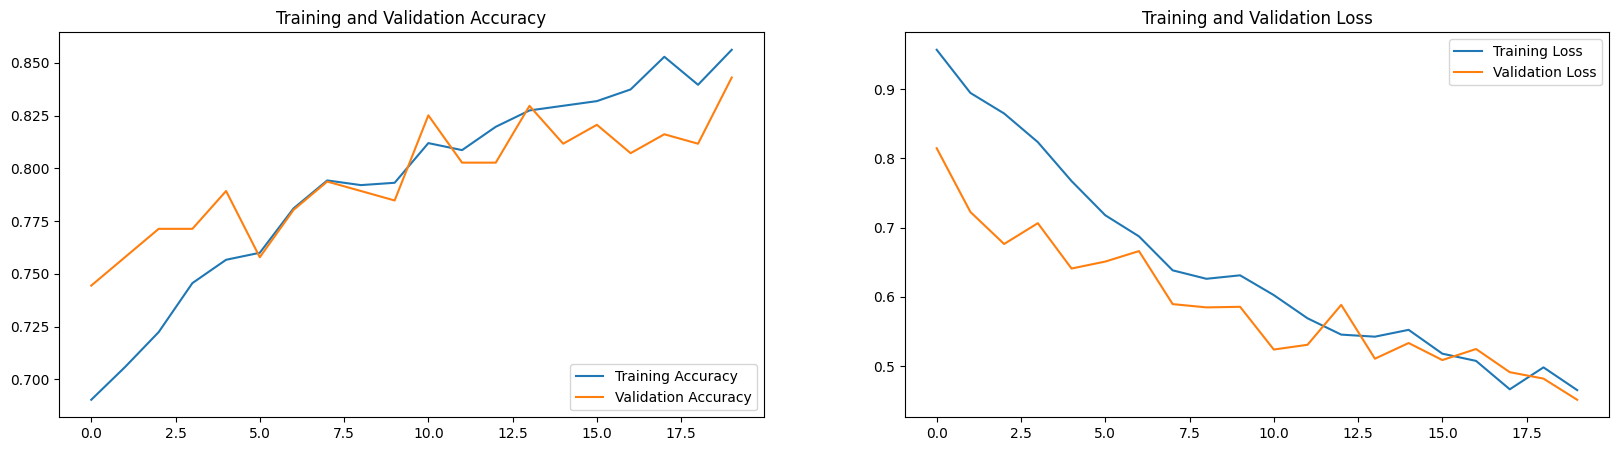

In [ ]:
def plot_training_history(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(20, 5))

    # Plot training and validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.show()




plot_training_history(history)

7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


<Axes: >

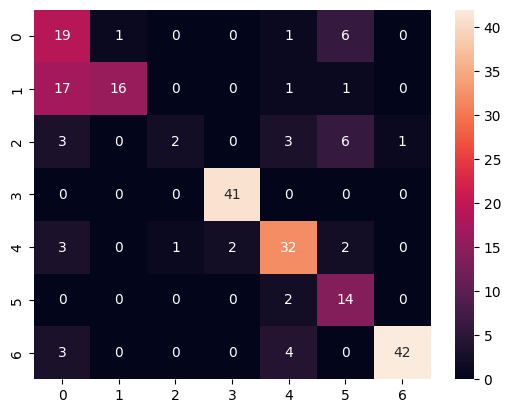

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(val_generator)
cm = confusion_matrix(val_generator.classes, y_pred.argmax(axis=1))
sns.heatmap(cm, annot=True, fmt='d')

In [ ]:
fer_model.save('ResNet50V2_ck.keras')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

In [ ]:

model1 = load_model('ResNet50V2_ck.keras')
fer_test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'test',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=64,
    shuffle=False
)

# Évaluer la performance
loss, acc = model1.evaluate(fer_test_generator)
print(f"Accuracy sur FER2013 : {acc:.2f}")


Found 7178 images belonging to 7 classes.


c:\Users\elfak\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


113/113 ━━━━━━━━━━━━━━━━━━━━ 454s 4s/step - accuracy: 0.5522 - loss: 1.2679
Accuracy sur FER2013 : 0.61


In [ ]:
model1 = load_model('ResNet50V2_ck.keras')
fer_test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'CK+48',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=64,
    shuffle=False
)

# Évaluer la performance
loss, acc = model1.evaluate(fer_test_generator)
print(f"Accuracy sur FER2013 : {acc:.2f}")

Found 1127 images belonging to 7 classes.
18/18 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.8127 - loss: 0.5256
Accuracy sur FER2013 : 0.88
